# Static Posture Analysis

Welcome to the first deep-dive tutorial! In expressive movement and biomechanical analysis, we often need to evaluate the spatial geometry of the body at a specific point in time, completely independent of how fast the subject is moving.

In this notebook, we will explore Contraction and Expansion. We will calculate two distinct geometric metrics:
1. Contraction Index: Compares the surface area of the body's Convex Hull (the tightest geometric wrapper) to its Axis-Aligned Bounding Box (AABB).

2. Points Density: Calculates the average dispersion (distance) of all joints from the body's barycenter (center of mass).

## Loading the Data
As always, we begin by loading our motion capture data into our standard 3D tensor format: (Time, Joints, Dimensions). Since static features only care about spatial coordinates, we will only be using the `pos_tensor`.

In [2]:
from utils.data_loader import load_qualisys_tsv
from utils.plot_utils import plot_feature_timeseries

# Load the data
pos_tensor, _, _, marker_names = load_qualisys_tsv("data/trial0001_impulsive.tsv")
N_frames, N_joints, N_dims = pos_tensor.shape

print(f"Loaded {N_frames} frames tracking {N_joints} joints.")

Loaded 7289 frames tracking 26 joints.


## Setting up Static Features

Because these features are static, they do not need historical data to compute a result. Therefore, we can set the `SlidingWindow` maximum length to exactly

*Note on the Math: The Contraction Index evaluates how much space the body takes up relative to its absolute dimensional limits.*

$$Contraction Index = \frac{SurfaceArea_{Hull}^2}{SurfaceArea_{BBox}}$$

When a dancer throws their arms and legs wide, their Convex Hull stretches to fill their Bounding Box, resulting in a high Contraction Index (Expansion). When they curl into a tight ball, the index drops.

In [3]:
from pyeyesweb.data_models.sliding_window import SlidingWindow
from pyeyesweb.low_level.contraction_expansion import BoundingBoxFilledArea, PointsDensity

# 1. Initialize Window
# A static feature only needs the most recent frame!
sw_pos = SlidingWindow(max_length=1, n_signals=N_joints, n_dims=3)

# 2. Initialize Features
contraction_feature = BoundingBoxFilledArea()
density_feature = PointsDensity()

## The Execution Loop
We iterate through the spatial data frame-by-frame.

Processing Geometry: 100%|██████████| 7289/7289 [00:04<00:00, 1541.95it/s]


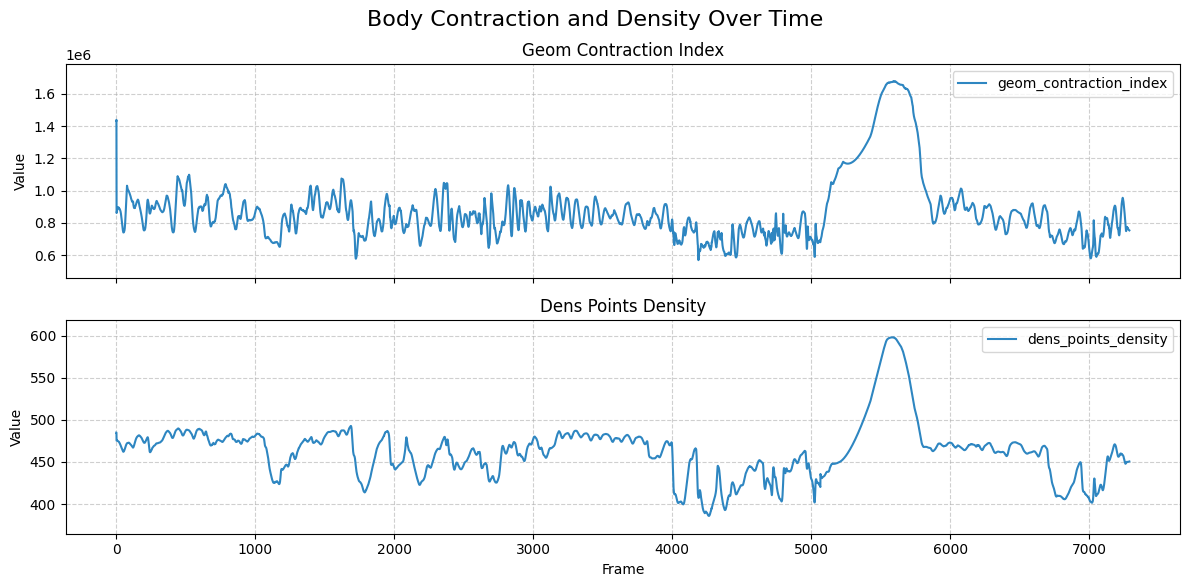

In [5]:
from tqdm.auto import tqdm

results = []

# Iterate through the positions tensor
for pos_frame in tqdm(pos_tensor, desc="Processing Geometry"):

    # 1. Push the new frame into the window
    sw_pos.append(pos_frame)

    # 2. Wait for the window to fill (Trivial for length 1, but good practice!)
    if len(sw_pos) < sw_pos.max_length:
        continue

    # 3. Compute features. Both return a ContractionExpansionResult dataclass.
    res_contract = contraction_feature(sw_pos).to_flat_dict("geom")
    res_density = density_feature(sw_pos).to_flat_dict("dens")

    # 4. Merge and store
    results.append(res_contract | res_density)


# Plotting the results
desired_metrics = [
    "geom_contraction_index",
    "dens_points_density"
]

plot_feature_timeseries(
    results_list=results,
    metrics_to_plot=desired_metrics,
    title="Body Contraction and Density Over Time"
)

**Interpreting the Plot**

Look at the graphs above:

`geom_contraction_index`: Spikes in this graph indicate moments of maximum physical expansion (e.g., limbs outstretched to the sides). Troughs indicate moments of physical contraction.

`dens_points_density`: Notice how closely this mirrors the Contraction Index! As the limbs stretch outward, the average distance of the joints from the center of mass inherently increases. Using both metrics allows Machine Learning models to capture a highly robust understanding of the subject's posture.